In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_moons, make_blobs
plt.style.use('ggplot')

In [36]:
def plot_decision_boundary(model, X, y, xlim=(-1.5, 2.5), ylim=(-1, 1.5), grid_size=100):
    x1 = np.linspace(*xlim, grid_size)
    x2 = np.linspace(*ylim, grid_size)
    xx1, xx2 = np.meshgrid(x1, x2)
    grid = np.c_[xx1.ravel(), xx2.ravel()]
    logits = model.forward(grid, training=False).value  # (grid_size², C)
    if logits.shape[1] == 1:
        pred = (logits > 0).reshape(xx1.shape)          # binary: threshold at 0
    else:
        pred = np.argmax(logits, axis=1).reshape(xx1.shape)  # multi-class: argmax
    plt.contourf(xx1, xx2, pred, alpha=0.3)
    plt.scatter(X[:,0], X[:,1], c=y, edgecolor='k')

In [23]:
# ── He initialisation ──────────────────────────────────────────────
def he_init(fan_in, fan_out, rng=np.random.default_rng()):
    return rng.normal(0, np.sqrt(2 / fan_in), (fan_in, fan_out))

# ── broadcast helper ───────────────────────────────────────────────
def _sum_to(grad, shape):
    """Sum grad down to `shape`, undoing any numpy broadcasting.
    The problem it solves is this: numpy broadcasting expands smaller arrays to match larger shapes during 
    forward operations, but gradients must flow back to the original shape of each operand.
    
    For example, if we have a forward operation like this:
    a = np.array([[1, 2], [3, 4]])  # shape (2, 2) # batch of 2 samples, 2 features
    b = np.array([10, 20])           # shape (2,)
    c = a + b                        # shape (2, 2) due to broadcasting (2 batch samples)
    Then during backpropagation, the gradient of c with respect to a and b will also have shape (2, 2). However, we need to sum the gradients back to the original shapes of a and b:
    da = np.array([[1, 1], [1, 1]])  # shape (2, 2)
    db = np.array([[1, 1], [1, 1]])  # shape (2, 2) due to broadcasting
    To get the correct gradients for a and b, we need to sum da and db back to the shapes of a and b:
    da_sum = da.sum(axis=0)          # shape (2,) - sum over rows to get back to shape of a
    db_sum = db.sum(axis=0)          # shape (2,) - sum over rows to get back to shape of b
    The _sum_to function automates this process by summing the gradients down to the specified shape, effectively undoing the effects of broadcasting during the forward pass.
    """
    
    while grad.ndim > len(shape):
        grad = grad.sum(axis=0)
    for axis, (s, g) in enumerate(zip(shape, grad.shape)):
        if s < g:
            grad = grad.sum(axis=axis, keepdims=True)
    return grad

# ── computation graph node ─────────────────────────────────────────
class Parameter:
    def __init__(self, value, parents=[]):
        self.value    = np.array(value, dtype=float) if not isinstance(value, np.ndarray) else value.astype(float)
        self.parents  = parents
        self.grad     = np.zeros_like(self.value, dtype=float)
        self._backward = lambda: None

    def __repr__(self):
        return f"Parameter(value={self.value}, grad={self.grad})"

    # ── arithmetic ─────────────────────────────────────────────────
    def __add__(self, b):
        if not isinstance(b, Parameter): b = Parameter(b)
        c = Parameter(self.value + b.value, parents=[self, b])
        def _backward():
            self.grad += _sum_to(c.grad, self.value.shape)
            b.grad    += _sum_to(c.grad, b.value.shape)
        c._backward = _backward
        return c

    def __radd__(self, b): 
        if not isinstance(b, Parameter): b = Parameter(b)
        return self.__add__(b)

    def __sub__(self, b):
        if not isinstance(b, Parameter): b = Parameter(b)
        c = Parameter(self.value - b.value, parents=[self, b])
        def _backward():
            self.grad += _sum_to( c.grad, self.value.shape)
            b.grad    += _sum_to(-c.grad, b.value.shape)
        c._backward = _backward
        return c

    def __rsub__(self, b):
        if not isinstance(b, Parameter): b = Parameter(b)
        return b.__sub__(self)

    def __neg__(self):
        c = Parameter(-self.value, parents=[self])
        def _backward(): self.grad -= c.grad
        c._backward = _backward
        return c

    def __mul__(self, b):               # element-wise
        if not isinstance(b, Parameter): b = Parameter(b)
        c = Parameter(self.value * b.value, parents=[self, b])
        def _backward():
            self.grad += _sum_to(b.value * c.grad, self.value.shape)
            b.grad    += _sum_to(self.value * c.grad, b.value.shape)
        c._backward = _backward
        return c

    def __rmul__(self, b): return self.__mul__(b)

    def __truediv__(self, b):           # element-wise
        if not isinstance(b, Parameter): b = Parameter(b)
        c = Parameter(self.value / b.value, parents=[self, b])
        def _backward():
            self.grad += _sum_to(c.grad / b.value, self.value.shape)
            b.grad    += _sum_to(-c.grad * self.value / b.value**2, b.value.shape)
        c._backward = _backward
        return c

    def __matmul__(self, b): # @ : matrix multiply
        if not isinstance(b, Parameter): b = Parameter(b)
        c = Parameter(np.matmul(self.value, b.value), parents=[self, b])
        def _backward():
            self.grad += np.matmul(c.grad, b.value.T)    # dX = dC W^T
            b.grad    += np.matmul(self.value.T, c.grad) # dW = X^T dC
        c._backward = _backward
        return c

    # ── activations ────────────────────────────────────────────────
    def relu(self):
        c = Parameter(np.maximum(0, self.value), parents=[self])
        def _backward(): self.grad += np.where(self.value > 0, c.grad, 0)
        c._backward = _backward
        return c

    def sigmoid(self):
        # f' = f * (1 - f) where f(x) = sigmoid(x) = 1 / (1 + exp(-x))
        s = 1 / (1 + np.exp(-np.clip(self.value, -100, 100)))
        c = Parameter(s, parents=[self])
        def _backward(): self.grad += s * (1 - s) * c.grad
        c._backward = _backward
        return c

    def log(self):
        c = Parameter(np.log(self.value + 1e-9), parents=[self])
        def _backward(): self.grad += c.grad / (self.value + 1e-9)
        c._backward = _backward
        return c

    def exp(self):
        c = Parameter(np.exp(self.value), parents=[self])
        def _backward(): self.grad += c.value * c.grad
        c._backward = _backward
        return c

    def mean(self, axis=None):
        size = self.value.shape[axis] if axis is not None else self.value.size
        c = Parameter(self.value.mean(axis=axis), parents=[self])
        def _backward(): self.grad += np.ones_like(self.value) / size * c.grad
        c._backward = _backward
        return c
    
    def var(self, axis=None):
        size = self.value.shape[axis] if axis is not None else self.value.size
        c = Parameter(self.value.var(axis=axis), parents=[self])
        def _backward(): self.grad += 2 * (self.value - self.value.mean(axis=axis)) / size * c.grad
        c._backward = _backward
        return c
    
    def sqrt(self):
        c = Parameter(np.sqrt(self.value), parents=[self])
        def _backward(): self.grad += 0.5 / np.sqrt(self.value) * c.grad
        c._backward = _backward
        return c

    def sum(self, axis=None, keepdims=False):
        c = Parameter(self.value.sum(axis=axis, keepdims=keepdims), parents=[self])
        def _backward():
            grad = c.grad
            if axis is not None and not keepdims:
                grad = np.expand_dims(grad, axis=axis)  # restore the summed dimension for broadcasting
            self.grad += np.ones_like(self.value) * grad
        c._backward = _backward
        return c

    # ── graph traversal ────────────────────────────────────────────
    def backward(self):
        topo, visited = [], set()
        def build(v):
            if v not in visited:
                visited.add(v)
                for p in v.parents: build(p)
                topo.append(v)
        build(self)
        self.grad = np.ones_like(self.value, dtype=float)
        for node in reversed(topo):
            node._backward()

    def zero_grad(self):
        visited = set()
        def dfs(n):
            if n not in visited:
                visited.add(n)
                for p in n.parents: dfs(p)
        dfs(self)
        for n in visited:
            n.grad = np.zeros_like(n.value, dtype=float)


In [20]:
class Layer:
    def forward(self, x, training=True):pass
    def __call__(self, x, training=True): return self.forward(x, training)
    def backward(self, dout):pass
    def get_params(self):return []
    
# ── linear ─────────────────────────────────────────────────────────
class Linear(Layer):
    def __init__(self, in_dim, out_dim, rng=np.random.default_rng()):
        self.W = Parameter(he_init(in_dim, out_dim, rng))  # (in, out)
        self.b = Parameter(np.zeros(out_dim))              # (out,) — _sum_to handles the batch broadcast

    def forward(self, x, training=True):
        return x @ self.W + self.b                    # (B, in) @ (in, out) + (out,) → (B, out)

    def get_params(self): return [self.W, self.b]


# ── dropout ────────────────────────────────────────────────────────
class Dropout(Layer):
    def __init__(self, p=0.3):
        self.p = p

    def forward(self, x, training=True):
        if not training or self.p == 0: return x
        mask = (np.random.rand(*x.value.shape) > self.p) / (1 - self.p)
        out  = Parameter(x.value * mask, parents=[x])
        def _backward(): x.grad += mask * out.grad   # reuse the same mask from forward
        out._backward = _backward
        return out

# ── batch normalisation ────────────────────────────────────────────
class BatchNorm(Layer):
    def __init__(self, dim, eps=1e-8, momentum=0.9):
        self.gamma = Parameter(np.ones(dim))                  # learned scale
        self.beta = Parameter(np.zeros(dim))                 # learned shift

        self.eps = eps
        self.mom = momentum
        self.running_mean = np.zeros(dim)          # for inference
        self.running_var  = np.ones(dim)
        # cache for backprop
        self._xhat = None
        self._std = None
        self._x_mu = None

    def forward(self, x, training=True):
        if training:
            mu  = x.mean(axis=0)
            var = x.var(axis=0)
            self.running_mean = self.mom*self.running_mean + (1-self.mom)*mu.value
            self.running_var  = self.mom*self.running_var  + (1-self.mom)*var.value
        else:
            mu, var = self.running_mean, self.running_var
        self._std   = (var + self.eps).sqrt() if training else np.sqrt(var + self.eps)
        self._x_mu  = x - mu
        self._xhat  = self._x_mu / self._std       # normalised
        return self.gamma * self._xhat + self.beta

    def get_params(self): return [self.gamma, self.beta]

In [21]:
def binary_cross_entropy(logits, y):
    """logits: Node (B, 1) — raw scores; y: numpy (B,)"""
    yhat = logits.sigmoid()
    y_n  = Parameter(y.reshape(yhat.value.shape))# (B, 1)
    ones = Parameter(np.ones(yhat.value.shape)) 
    return -(y_n * yhat.log() + (ones - y_n) * (ones - yhat).log()).mean()

def categorical_cross_entropy(logits, y):
    """logits: Node (B, C) — raw scores; y: numpy (B,) with class indices"""
    exps = logits.exp()
    probs = exps / exps.sum(axis=1, keepdims=True) # (B, C) / (B, 1) → softmax probabilities
    y_n = Parameter(np.eye(probs.value.shape[1])[y]) # one-hot encode
    return -(y_n * probs.log()).sum(axis=1).mean() # Loss 

def mse_loss(pred, target):
    """pred: Node (B, D) — predictions; target: numpy (B, D) — true values"""
    target_n = Parameter(target) # (B, D)
    return ((pred - target_n)**2).mean()


In [7]:
# ── Adam optimiser ─────────────────────────────────────────────────
class Adam:
    def __init__(self, model_params, lr=0.001, b1=0.9, b2=0.999, eps=1e-8):
        self.lr, self.b1, self.b2, self.eps = lr, b1, b2, eps
        self.m, self.v, self.t = {}, {}, 0
        for p in model_params:
            k = id(p)
            self.m[k] = np.zeros_like(p.value)
            self.v[k] = np.zeros_like(p.value)


    def step(self, params):
        self.t += 1
        for param in params:
            k = id(param)
            self.m[k]   = self.b1*self.m[k] + (1-self.b1)*param.grad
            self.v[k]   = self.b2*self.v[k] + (1-self.b2)*param.grad**2
            mhat        = self.m[k] / (1 - self.b1**self.t)
            vhat        = self.v[k] / (1 - self.b2**self.t)
            param.value -= self.lr * mhat / (np.sqrt(vhat) + self.eps)

In [8]:
# ── residual block ─────────────────────────────────────────────────
class ResidualBlock:
    def __init__(self, dim):
        self.l1   = Linear(dim, dim)
        self.l2   = Linear(dim, dim)
        self.drop = Dropout(p=0.1)

    def __call__(self, x, training=True):
        return self.forward(x, training)

    def forward(self, x, training=True):
        out = self.l1.forward(x).relu()
        out = self.drop.forward(out, training)
        out = self.l2.forward(out)
        return out + x

    def get_params(self):
        return self.l1.get_params() + self.l2.get_params()


# ── graph network ──────────────────────────────────────────────────
class GraphNetwork:
    def __init__(self, in_dim=2, hidden_dim=16, out_dim=1):
        self.embed = Linear(in_dim, hidden_dim)
        self.res1  = ResidualBlock(hidden_dim)
        self.bn1   = BatchNorm(hidden_dim)
        self.res2  = ResidualBlock(hidden_dim)
        self.head  = Linear(hidden_dim, out_dim)
        

    def __call__(self, x, training=True): return self.forward(x, training)
    
    def forward(self, x, training=True):
        if not isinstance(x, Parameter): x = Parameter(x)
        out = self.embed.forward(x).relu()
        out = self.res1.forward(out, training)
        out = self.bn1.forward(out, training)
        out = self.res2.forward(out, training)
        return self.head.forward(out) # (B, 1) logits

    def get_params(self):
        return (self.embed.get_params() +
                self.res1.get_params()  +
                self.bn1.get_params()   +
                self.res2.get_params()  +
                self.head.get_params())

In [9]:
# ── training loop ──────────────────────────────────────────────────
def train(model, opt, X, y, epochs=100, batch_size=32,
          loss_fn=binary_cross_entropy):
    history, n = [], len(X)
    for _ in range(epochs):
        idx = np.random.permutation(n)
        epoch_loss, n_batches = 0.0, 0
        for i in range(0, n, batch_size):
            b    = idx[i:i+batch_size]
            loss = loss_fn(model.forward(X[b], training=True), y[b])
            loss.zero_grad()  # reset gradients before backward pass
            loss.backward()
            opt.step(model.get_params())
            epoch_loss += float(loss.value)
            n_batches  += 1
        history.append(epoch_loss / n_batches)
    return history

/var/folders/cn/kt4mzqx94nscy_sncr2dpybc0000gn/T/ipykernel_7517/1191729533.py:97: RuntimeWarning: divide by zero encountered in matmul
  c = Parameter(np.matmul(self.value, b.value), parents=[self, b])
/var/folders/cn/kt4mzqx94nscy_sncr2dpybc0000gn/T/ipykernel_7517/1191729533.py:97: RuntimeWarning: overflow encountered in matmul
  c = Parameter(np.matmul(self.value, b.value), parents=[self, b])
/var/folders/cn/kt4mzqx94nscy_sncr2dpybc0000gn/T/ipykernel_7517/1191729533.py:97: RuntimeWarning: invalid value encountered in matmul
  c = Parameter(np.matmul(self.value, b.value), parents=[self, b])
/var/folders/cn/kt4mzqx94nscy_sncr2dpybc0000gn/T/ipykernel_7517/1191729533.py:99: RuntimeWarning: divide by zero encountered in matmul
  self.grad += np.matmul(c.grad, b.value.T)    # dX = dC W^T
/var/folders/cn/kt4mzqx94nscy_sncr2dpybc0000gn/T/ipykernel_7517/1191729533.py:99: RuntimeWarning: overflow encountered in matmul
  self.grad += np.matmul(c.grad, b.value.T)    # dX = dC W^T
/var/folders/cn

Text(0.5, 1.0, 'Training Loss')

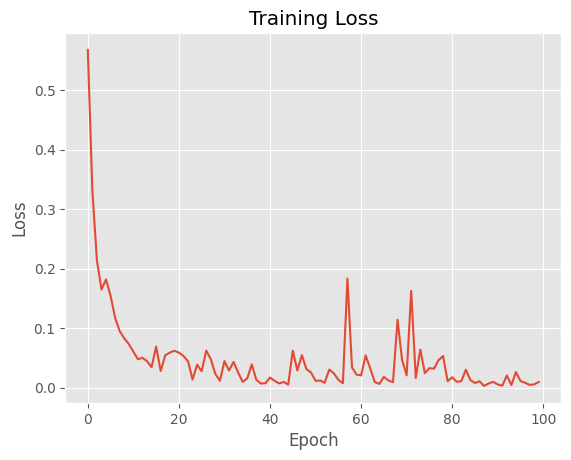

In [37]:
# ── demo ───────────────────────────────────────────────────────────
X_data, y_data = make_moons(n_samples=200, noise=0.1, random_state=0)

model = GraphNetwork()
opt   = Adam(model.get_params(), lr=0.005)
h     = train(model, opt, X_data, y_data)

plt.plot(h)
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training Loss')

/var/folders/cn/kt4mzqx94nscy_sncr2dpybc0000gn/T/ipykernel_7517/1191729533.py:97: RuntimeWarning: divide by zero encountered in matmul
  c = Parameter(np.matmul(self.value, b.value), parents=[self, b])
/var/folders/cn/kt4mzqx94nscy_sncr2dpybc0000gn/T/ipykernel_7517/1191729533.py:97: RuntimeWarning: overflow encountered in matmul
  c = Parameter(np.matmul(self.value, b.value), parents=[self, b])
/var/folders/cn/kt4mzqx94nscy_sncr2dpybc0000gn/T/ipykernel_7517/1191729533.py:97: RuntimeWarning: invalid value encountered in matmul
  c = Parameter(np.matmul(self.value, b.value), parents=[self, b])


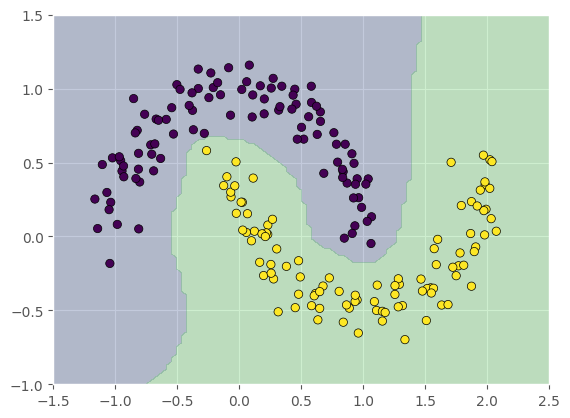

In [38]:
plot_decision_boundary(model, X_data, y_data, xlim=(-1.5, 2.5), ylim=(-1, 1.5))

## Categorical cross entropy

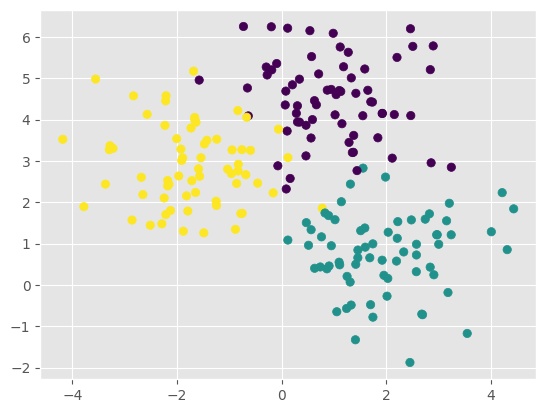

In [39]:
X, y = make_blobs(n_samples=200, centers=3, random_state=0)
plt.scatter(X[:,0], X[:,1], c=y)

/var/folders/cn/kt4mzqx94nscy_sncr2dpybc0000gn/T/ipykernel_7517/1191729533.py:97: RuntimeWarning: divide by zero encountered in matmul
  c = Parameter(np.matmul(self.value, b.value), parents=[self, b])
/var/folders/cn/kt4mzqx94nscy_sncr2dpybc0000gn/T/ipykernel_7517/1191729533.py:97: RuntimeWarning: overflow encountered in matmul
  c = Parameter(np.matmul(self.value, b.value), parents=[self, b])
/var/folders/cn/kt4mzqx94nscy_sncr2dpybc0000gn/T/ipykernel_7517/1191729533.py:97: RuntimeWarning: invalid value encountered in matmul
  c = Parameter(np.matmul(self.value, b.value), parents=[self, b])
/var/folders/cn/kt4mzqx94nscy_sncr2dpybc0000gn/T/ipykernel_7517/1191729533.py:99: RuntimeWarning: divide by zero encountered in matmul
  self.grad += np.matmul(c.grad, b.value.T)    # dX = dC W^T
/var/folders/cn/kt4mzqx94nscy_sncr2dpybc0000gn/T/ipykernel_7517/1191729533.py:99: RuntimeWarning: overflow encountered in matmul
  self.grad += np.matmul(c.grad, b.value.T)    # dX = dC W^T
/var/folders/cn

Text(0.5, 1.0, 'Training Loss')

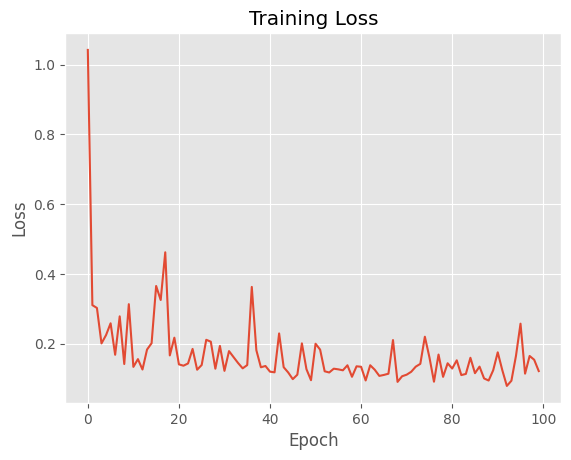

In [40]:
model = GraphNetwork(2, 16, 3) # 3 output classes for 3 blobs
opt   = Adam(model.get_params(), lr=0.01)
h     = train(model, opt, X, y, loss_fn=categorical_cross_entropy)

plt.plot(h)
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training Loss')

/var/folders/cn/kt4mzqx94nscy_sncr2dpybc0000gn/T/ipykernel_7517/1191729533.py:97: RuntimeWarning: divide by zero encountered in matmul
  c = Parameter(np.matmul(self.value, b.value), parents=[self, b])
/var/folders/cn/kt4mzqx94nscy_sncr2dpybc0000gn/T/ipykernel_7517/1191729533.py:97: RuntimeWarning: overflow encountered in matmul
  c = Parameter(np.matmul(self.value, b.value), parents=[self, b])
/var/folders/cn/kt4mzqx94nscy_sncr2dpybc0000gn/T/ipykernel_7517/1191729533.py:97: RuntimeWarning: invalid value encountered in matmul
  c = Parameter(np.matmul(self.value, b.value), parents=[self, b])


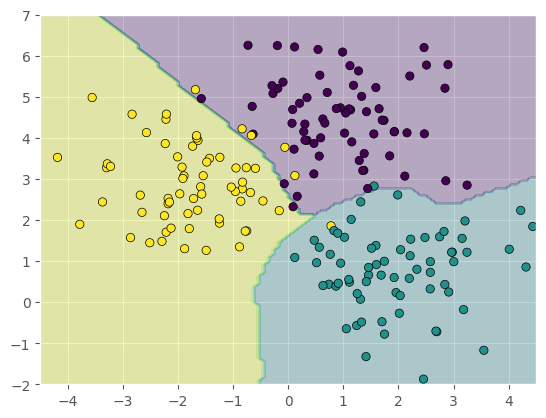

In [42]:
plot_decision_boundary(model, X, y, xlim=(-4.5, 4.5), ylim=(-2, 7))